Since the dataset from ICSD requires a hugging face token, the file ids must be configured before running this script.
## Configuring Notebook in Colab
If running in Colab, it is important to set the secret variables included in the final report. 
## Configuring Notebook in Local
Running in 

In [1]:
import sys
import os

# detect the environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# configure the paths
if IN_COLAB:
    print("Running in Google Colab. Setting up GitHub repo...")
    REPO_URL = "https://github.com/JayC-SF/COMP-432-Project.git"
    REPO_DIR = "/content/COMP-432-Project"

    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}

    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)

    # change the working directory
    os.chdir(REPO_DIR)
else:
    print("Running locally. Setting up relative paths...")
    # move up only if base directory is at notebooks
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
        print(f"Working directory changed to: {os.getcwd()}")

    # add working dir to sys path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())

    %load_ext autoreload
    %autoreload 2

from src import preprocess_data as prepd
import src.variables as v
import numpy as np
import seaborn as sns


Running locally. Setting up relative paths...
Working directory changed to: /home/jcsf/school/4.winter2026/COMP432/project/COMP-432-Project


We first download the dataset and its metada from a google drive link. We then extract them into the `data/` folder from the root of the repository.

In [2]:
prepd.download_and_extract(v.AUDIO_ZIP_FILE_PATH, v.AUDIO_ZIP_GID, v.AUDIO_DATA_PATH)
prepd.download_and_extract(v.METADATA_ZIP_FILE_PATH, v.METADATA_ZIP_GID, v.METADATA_PATH)

data/audio already exists.
data/metadata already exists.


You can find the dataset distribution of the durations. As it can be seen below the distribution is heavily composed of audio sounds of 10 seconds.

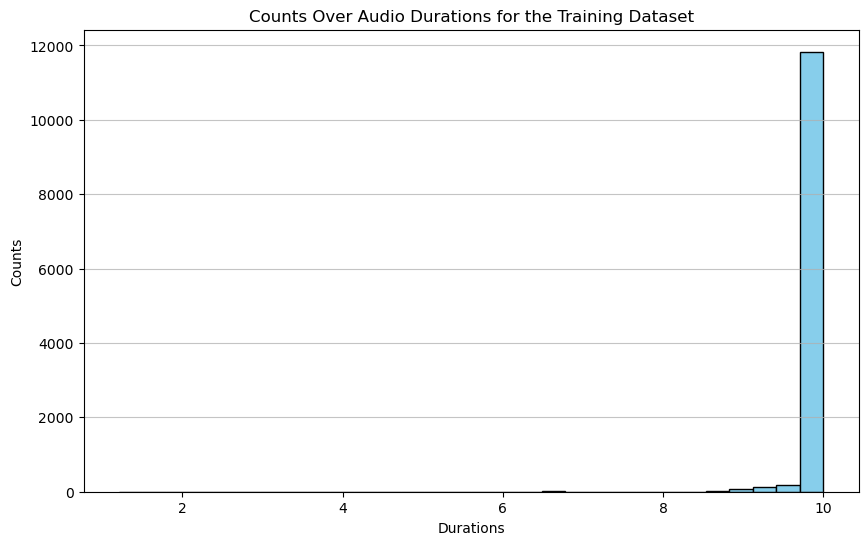

{10.0: 11472, 9.088027210884354: 2, 9.993015873015873: 141, 9.443219954648526: 1, 7.314331065759637: 1, 9.275283446712018: 1, 9.399455782312925: 1, 9.117777777777778: 2, 9.425759637188209: 1, 9.865532879818595: 1, 9.999954648526078: 26, 9.99859410430839: 1, 9.466167800453515: 1, 9.016689342403629: 4, 9.462539682539683: 1, 9.955510204081632: 1, 9.077913832199547: 1, 9.735510204081633: 1, 9.371655328798186: 2, 9.855646258503402: 2, 9.175419501133787: 3, 9.413514739229026: 1, 9.611519274376418: 2, 9.416916099773243: 1, 9.508979591836734: 1, 9.394331065759637: 2, 9.077777777777778: 1, 9.902222222222223: 1, 6.548072562358277: 1, 9.972380952380952: 2, 9.553151927437641: 2, 9.847165532879819: 1, 1.207437641723356: 1, 9.570158730158731: 1, 6.710566893424036: 3, 9.659229024943311: 1, 9.999591836734695: 6, 9.31233560090703: 1, 9.910385487528345: 1, 9.761814058956917: 1, 9.671156462585033: 1, 9.549251700680273: 2, 9.52907029478458: 1, 9.243219954648525: 1, 10.000090702947846: 16, 9.71791383219954

In [39]:
_, durations = prepd.get_durations(v.AUDIO_DATA_PATH/'train')
prepd.plot_durations(durations, "Counts Over Audio Durations for the Training Dataset")
print(prepd.count_durations(durations))

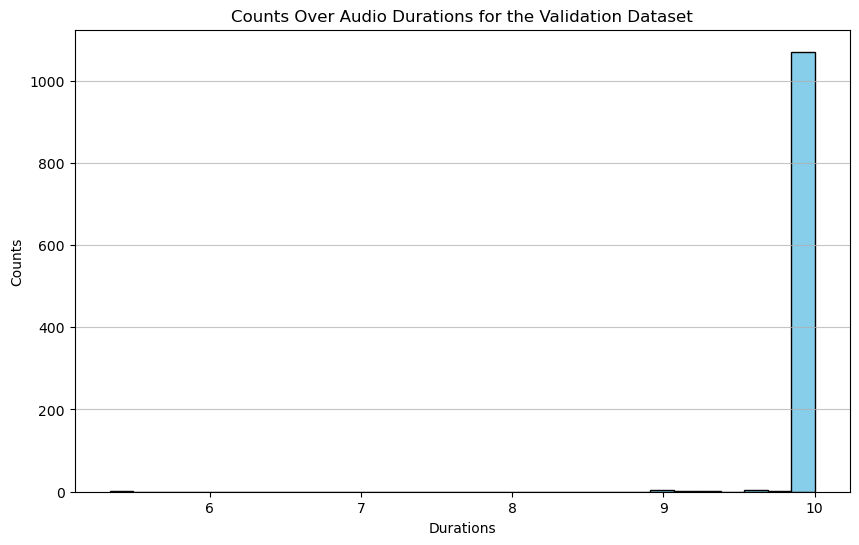

{10.0: 1061, 9.993015873015873: 6, 5.340634920634921: 1, 9.94907029478458: 1, 9.184353741496599: 1, 9.787256235827664: 1, 9.357641723356009: 1, 9.605668934240363: 1, 9.175419501133787: 1, 9.590068027210885: 1, 9.961451247165533: 1, 9.850068027210884: 1, 9.729206349206349: 1, 9.566349206349207: 1, 9.062312925170067: 1, 8.972607709750568: 1, 9.013605442176871: 1}


In [40]:
_, durations = prepd.get_durations(v.AUDIO_DATA_PATH/'validation')
prepd.plot_durations(durations, "Counts Over Audio Durations for the Validation Dataset")
print(prepd.count_durations(durations))

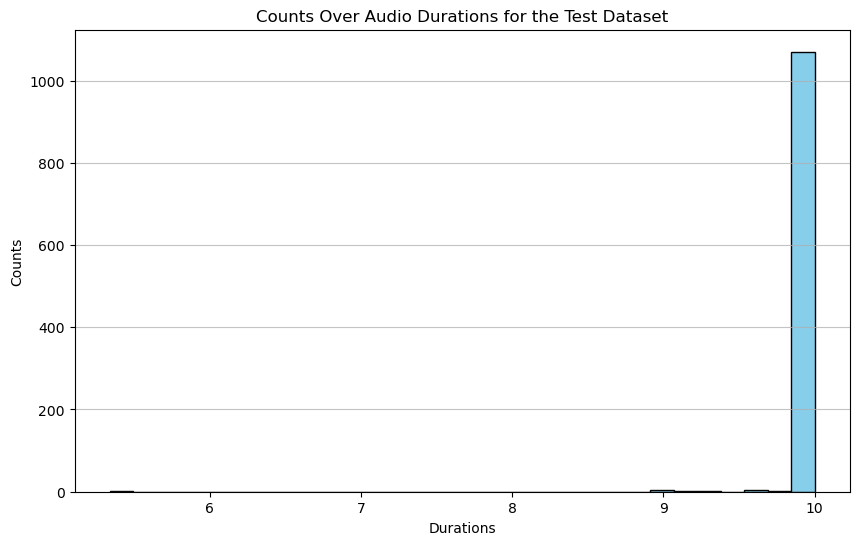

{10.0: 1061, 9.993015873015873: 6, 5.340634920634921: 1, 9.94907029478458: 1, 9.184353741496599: 1, 9.787256235827664: 1, 9.357641723356009: 1, 9.605668934240363: 1, 9.175419501133787: 1, 9.590068027210885: 1, 9.961451247165533: 1, 9.850068027210884: 1, 9.729206349206349: 1, 9.566349206349207: 1, 9.062312925170067: 1, 8.972607709750568: 1, 9.013605442176871: 1}


In [41]:
prepd.get_durations(v.AUDIO_DATA_PATH/'test')
prepd.plot_durations(durations, "Counts Over Audio Durations for the Test Dataset")
print(prepd.count_durations(durations))

Since we can see the dataset distribution is more than 95% of 10 seconds, we will pad the ones that have less duration with empty sounds before processing them into the models. In the following lines of code, we convert them to mel spectograms but perform no padding yet.

In [3]:
# convert data to mel spectograms
prepd.convert_audio_dataset_to_mel(v.AUDIO_DATA_PATH, v.MEL_SPECTOGRAM_PATH)

data/mel_spectogram already exists, skipping convertion...


The following transforms mel spectogram files into their respective split of training, validation, and test dataset all in numpy arrays.

It finally saves it all into a `.npz` file ready to be used for a training, validation and test pipeline.

In [ ]:
# Prepare the dataset and use the maximum length as the time dimension
X_train, y_train = prepd.load_mel_spec_to_dataset(v.MEL_SPECTOGRAM_PATH/'train')
# pass the fixed maximum time dimension found from the train dataset onto the validation and test dataset processing
X_val, y_val = prepd.load_mel_spec_to_dataset(v.MEL_SPECTOGRAM_PATH/'validation', timedim = X_train.shape[2])
X_test, y_test = prepd.load_mel_spec_to_dataset(v.MEL_SPECTOGRAM_PATH/'test', timedim = X_train.shape[2])

In [ ]:
np.savez_compressed(v.MEL_SPECTOGRAM_NPZ_FILE_PATH, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)

In [ ]:
data = np.load(v.MEL_SPECTOGRAM_NPZ_FILE_PATH)
X_train= data['X_train']
y_train= data['y_train']
X_val= data['X_val']
y_val= data['y_val']
X_test= data['X_test']
y_test= data['y_test']

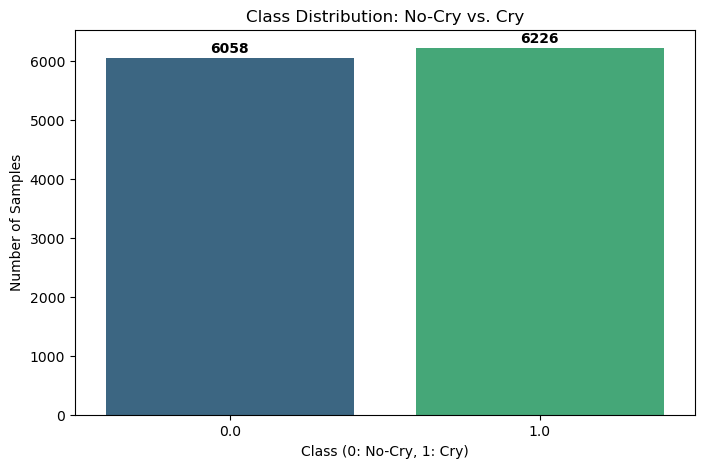

In [ ]:
from src.utils.plotting import plot_class_inbalance
plot_class_inbalance(y_train, "Training")

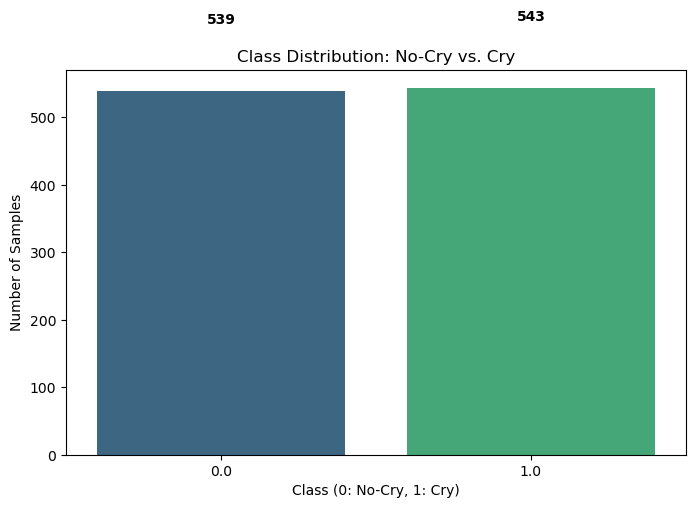

In [ ]:
plot_class_inbalance(y_val, "Validation")

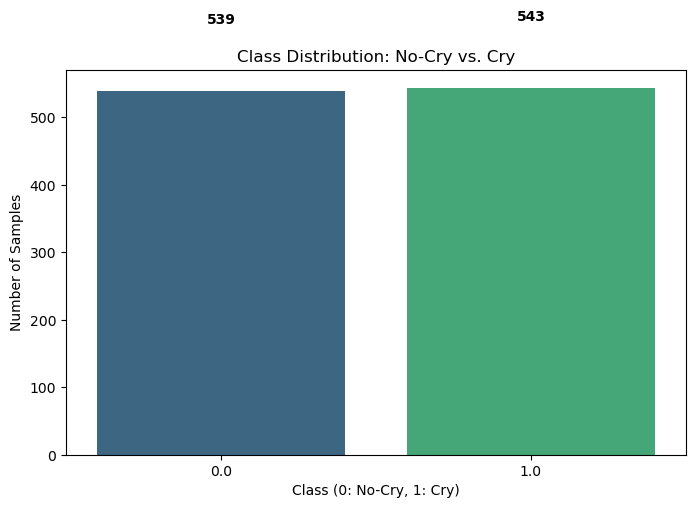

In [ ]:
plot_class_inbalance(y_test, "Testing")